# **Task 1.1: Create a simple model that analyzes text using an artificial neural network (ANN). Using Small Dataset**

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


[ANN with small dataset] Epoch 1/10, Loss: 0.6895, Val Acc: 0.8100
[ANN with small dataset] Epoch 2/10, Loss: 0.6281, Val Acc: 0.8300
[ANN with small dataset] Epoch 3/10, Loss: 0.4508, Val Acc: 0.8200
[ANN with small dataset] Epoch 4/10, Loss: 0.2359, Val Acc: 0.8200
[ANN with small dataset] Epoch 5/10, Loss: 0.1146, Val Acc: 0.8400
[ANN with small dataset] Epoch 6/10, Loss: 0.0639, Val Acc: 0.8400
[ANN with small dataset] Epoch 7/10, Loss: 0.0401, Val Acc: 0.8600
[ANN with small dataset] Epoch 8/10, Loss: 0.0277, Val Acc: 0.8600
[ANN with small dataset] Epoch 9/10, Loss: 0.0210, Val Acc: 0.8600
[ANN with small dataset] Epoch 10/10, Loss: 0.0163, Val Acc: 0.8600
[Embeddings]Validation Accuracy: 0.8600
              precision    recall  f1-score   support

           0       0.82      0.89      0.86        47
           1       0.90      0.83      0.86        53

    accuracy                           0.86       100
   macro avg       0.86      0.86      0.86       100
weighted avg     

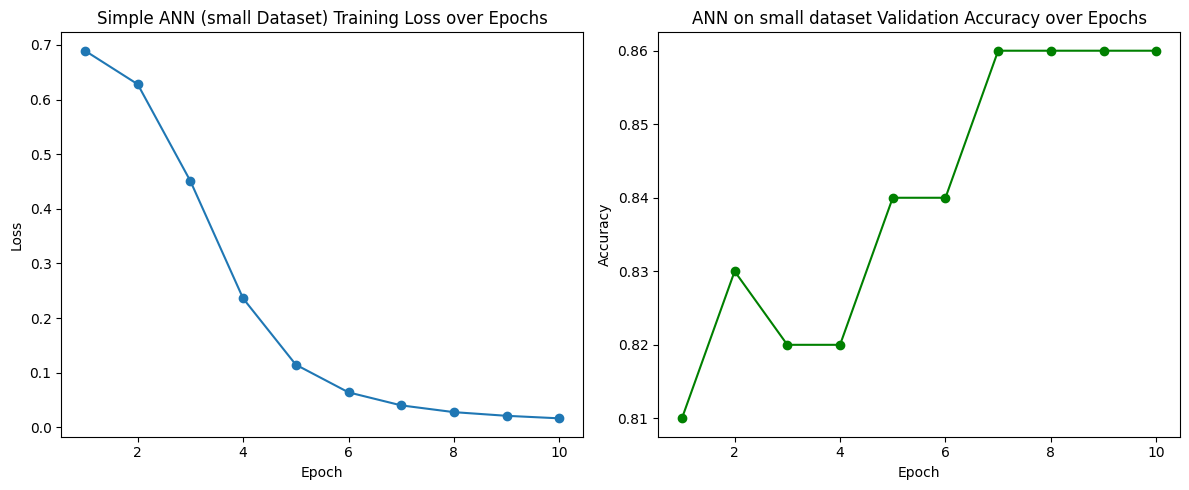

In [17]:
# Download required NLTK resources for tokenization and stopword removal
import nltk
nltk.download('punkt')
nltk.download('stopwords')

# Importing required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.corpus import stopwords
from nltk.tokenize import TreebankWordTokenizer
from sklearn.metrics import accuracy_score, classification_report

# Text preprocessing function using NLTK and regex
def preprocess_pandas(data, columns):
    df_ = pd.DataFrame(columns=columns)

    # Lowercasing all text
    data['Sentence'] = data['Sentence'].str.lower()

    # Removing email addresses, IP addresses, special characters, and numbers
    data['Sentence'] = data['Sentence'].replace('[a-zA-Z0-9-_.]+@[a-zA-Z0-9-_.]+', '', regex=True)
    data['Sentence'] = data['Sentence'].replace('((25[0-5]|2[0-4][0-9]|[01]?[0-9][0-9]?)(\.|$)){4}', '', regex=True)
    data['Sentence'] = data['Sentence'].str.replace('[^\w\s]', '', regex=True)
    data['Sentence'] = data['Sentence'].replace('\d', '', regex=True)

    tokenizer = TreebankWordTokenizer()

    # Tokenizing and removing stopwords
    for index, row in data.iterrows():
        word_tokens = tokenizer.tokenize(row['Sentence'])
        filtered_sent = [w for w in word_tokens if not w in stopwords.words('english')]
        df_.loc[len(df_)] = {
            "index": row['index'],
            "Class": row['Class'],
            "Sentence": " ".join(filtered_sent)
        }
    return df_

# Loads data, preprocesses it, vectorizes text using TF-IDF, and converts it to tensors
def load_data(file_path="amazon_cells_labelled.txt"):
    # Load raw data
    data = pd.read_csv(file_path, delimiter='\t', header=None)
    data.columns = ['Sentence', 'Class']
    data['index'] = data.index
    columns = ['index', 'Class', 'Sentence']

    # Preprocess text
    data = preprocess_pandas(data, columns)

    # Split into training and validation sets
    training_data, validation_data, training_labels, validation_labels = train_test_split(
        data['Sentence'].values.astype('U'),
        data['Class'].values.astype('int32'),
        test_size=0.10,
        random_state=0,
        shuffle=True
    )

    # TF-IDF vectorization of unigrams and bigrams
    word_vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1,2), max_features=50000, max_df=0.5, use_idf=True, norm='l2')
    training_data = word_vectorizer.fit_transform(training_data).todense()
    validation_data = word_vectorizer.transform(validation_data).todense()

    # Convert to PyTorch tensors
    train_x_tensor = torch.from_numpy(np.array(training_data)).float()
    train_y_tensor = torch.from_numpy(np.array(training_labels)).long()
    validation_x_tensor = torch.from_numpy(np.array(validation_data)).float()
    validation_y_tensor = torch.from_numpy(np.array(validation_labels)).long()

    return train_x_tensor, train_y_tensor, validation_x_tensor, validation_y_tensor

# Define a simple feedforward artificial neural network
class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleANN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)  # First hidden layer
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(128, 2)          # Output layer (2 classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Main script: training and evaluation
if __name__ == "__main__":
    # Load and prepare data
    train_x_tensor, train_y_tensor, validation_x_tensor, validation_y_tensor = load_data()

    batch_size = 32
    train_data = TensorDataset(train_x_tensor, train_y_tensor)
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    # Initialize model, loss function, and optimizer
    model = SimpleANN(train_x_tensor.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    epochs = 10
    train_losses = []
    val_accuracies = []

    # Training loop
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        
        # Track average training loss
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        # Evaluate on validation set
        model.eval()
        with torch.no_grad():
            outputs = model(validation_x_tensor)
            _, predicted = torch.max(outputs, 1)
            acc = (predicted == validation_y_tensor).float().mean()
            val_accuracies.append(acc)

        print(f"[ANN with small dataset] Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Val Acc: {acc:.4f}")

    # Final evaluation on validation data
    model.eval()
    with torch.no_grad():
        outputs = model(validation_x_tensor)
        _, predicted = torch.max(outputs, 1)
        accuracy = accuracy_score(validation_y_tensor, predicted)
        print(f"[Embeddings]Validation Accuracy: {accuracy:.4f}")
        print(classification_report(validation_y_tensor, predicted))

    # Plot training loss and validation accuracy
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, marker='o')
    plt.title("Simple ANN (small Dataset) Training Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), val_accuracies, marker='o', color='green')
    plt.title("ANN on small dataset Validation Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.tight_layout()
    plt.show()


# **Task 1.2: Impelement ANN with word embeddings and implement Transformer model in Pytorch on large multi lable dataset**

[Embeddings] Epoch 1/10, Loss: 0.3605, Val Acc: 0.8700
[Embeddings] Epoch 2/10, Loss: 0.3095, Val Acc: 0.8720
[Embeddings] Epoch 3/10, Loss: 0.2943, Val Acc: 0.8812
[Embeddings] Epoch 4/10, Loss: 0.2806, Val Acc: 0.8852
[Embeddings] Epoch 5/10, Loss: 0.2664, Val Acc: 0.8844
[Embeddings] Epoch 6/10, Loss: 0.2531, Val Acc: 0.8848
[Embeddings] Epoch 7/10, Loss: 0.2421, Val Acc: 0.8832
[Embeddings] Epoch 8/10, Loss: 0.2305, Val Acc: 0.8892
[Embeddings] Epoch 9/10, Loss: 0.2184, Val Acc: 0.8824
[Embeddings] Epoch 10/10, Loss: 0.2060, Val Acc: 0.8892
[Embeddings]Validation Accuracy: 0.8892
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       965
           1       0.92      0.90      0.91      1535

    accuracy                           0.89      2500
   macro avg       0.88      0.89      0.88      2500
weighted avg       0.89      0.89      0.89      2500



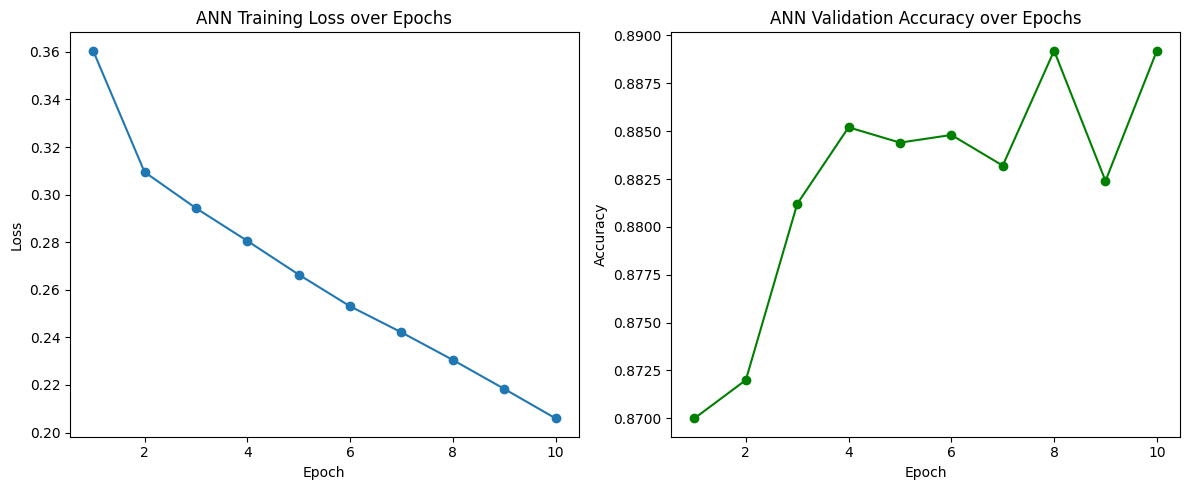

/usr/local/lib/python3.11/dist-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


[Transformer] Epoch 1/10, Loss: 0.3534, Val Acc: 0.8684
[Transformer] Epoch 2/10, Loss: 0.3109, Val Acc: 0.8780
[Transformer] Epoch 3/10, Loss: 0.2907, Val Acc: 0.8820
[Transformer] Epoch 4/10, Loss: 0.2787, Val Acc: 0.8752
[Transformer] Epoch 5/10, Loss: 0.2682, Val Acc: 0.8764
[Transformer] Epoch 6/10, Loss: 0.2540, Val Acc: 0.8832
[Transformer] Epoch 7/10, Loss: 0.2432, Val Acc: 0.8884
[Transformer] Epoch 8/10, Loss: 0.2307, Val Acc: 0.8820
[Transformer] Epoch 9/10, Loss: 0.2200, Val Acc: 0.8764
[Transformer] Epoch 10/10, Loss: 0.2082, Val Acc: 0.8780
[Transformer] Validation Accuracy: 0.8780
              precision    recall  f1-score   support

           0       0.81      0.89      0.85       965
           1       0.93      0.87      0.90      1535

    accuracy                           0.88      2500
   macro avg       0.87      0.88      0.87      2500
weighted avg       0.88      0.88      0.88      2500



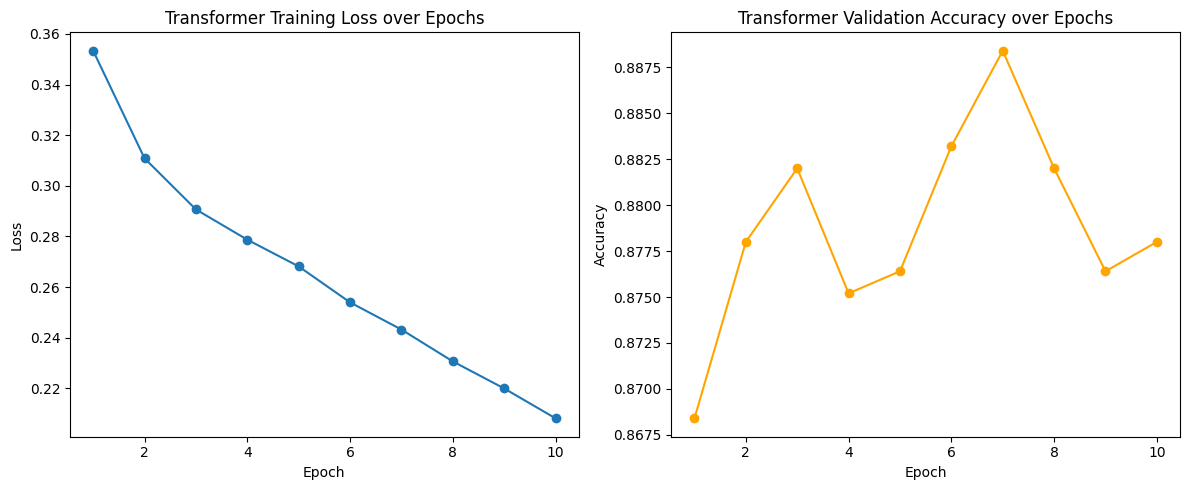

In [11]:
# Importing required libraries for model building, evaluation, and data manipulation
import torch  # Core PyTorch library
import torch.nn as nn  # Neural network components
import torch.optim as optim  # Optimizers like Adam
from torch.utils.data import TensorDataset, DataLoader  # For batching and loading data
import pandas as pd  # For data handling and CSV reading
import numpy as np  # For numerical operations
from sklearn.model_selection import train_test_split  # For splitting dataset
from sentence_transformers import SentenceTransformer  # For generating sentence embeddings
from sklearn.metrics import accuracy_score, classification_report  # Evaluation metrics
import matplotlib.pyplot as plt  # For plotting graphs

# Function to load data and convert sentences to sentence-level embeddings using a transformer model
def load_data_with_sentence_embeddings(file_path="amazon_cells_labelled_LARGE_25K.txt"):
    data = pd.read_csv(file_path, delimiter='\t', header=None)  # Load the TSV dataset
    data.columns = ['Sentence', 'Class']  # Name the columns
    data.dropna(inplace=True)  # Remove any rows with missing data

    # Split the dataset into training and validation sets (90% / 10%)
    train_sentences, val_sentences, train_labels, val_labels = train_test_split(
        data['Sentence'].values.astype('U'),
        data['Class'].values.astype('int32'),
        test_size=0.1,
        random_state=42,
        shuffle=True
    )

    # Generate sentence embeddings using a pre-trained MiniLM model
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    train_embeddings = embedder.encode(train_sentences.tolist(), convert_to_numpy=True)
    val_embeddings = embedder.encode(val_sentences.tolist(), convert_to_numpy=True)

    # Convert the embeddings and labels into PyTorch tensors
    train_x_tensor = torch.tensor(train_embeddings).float()
    train_y_tensor = torch.tensor(train_labels).long()
    val_x_tensor = torch.tensor(val_embeddings).float()
    val_y_tensor = torch.tensor(val_labels).long()

    return train_x_tensor, train_y_tensor, val_x_tensor, val_y_tensor

# Define a simple Artificial Neural Network (ANN) for binary classification
class SimpleANN(nn.Module):
    def __init__(self, input_dim):
        super(SimpleANN, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)  # First fully connected layer
        self.relu = nn.ReLU()  # Activation function
        self.fc2 = nn.Linear(128, 2)  # Output layer (2 classes)

    def forward(self, x):
        x = self.relu(self.fc1(x))  # Apply first layer + activation
        x = self.fc2(x)  # Output logits
        return x

# Define a Transformer-based classifier for sentence embeddings
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim, emb_dim=128, n_heads=4, ff_dim=256, num_layers=2, num_classes=2):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Linear(input_dim, emb_dim)  # Project input to embedding dimension
        encoder_layer = nn.TransformerEncoderLayer(d_model=emb_dim, nhead=n_heads, dim_feedforward=ff_dim)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Linear(emb_dim, num_classes)  # Output layer

    def forward(self, x):
        x = self.embedding(x).unsqueeze(1)  # Add sequence dimension (batch, seq_len=1, emb_dim)
        x = self.transformer(x)  # Pass through Transformer layers
        x = x.mean(dim=1)  # Pool across sequence dimension
        return self.fc(x)  # Output logits

# Run training and evaluation
if __name__ == "__main__":
    # Load training and validation tensors
    train_x_tensor, train_y_tensor, val_x_tensor, val_y_tensor = load_data_with_sentence_embeddings()

    # Wrap training tensors in a DataLoader for batching
    batch_size = 32
    train_dataset = TensorDataset(train_x_tensor, train_y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Initialize ANN model, loss function, and optimizer
    model = SimpleANN(train_x_tensor.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Track metrics during training
    epochs = 10
    train_losses = []
    val_accuracies = []

    # Train the ANN model
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Calculate average loss and validation accuracy
        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        with torch.no_grad():
            outputs = model(val_x_tensor)
            _, predicted = torch.max(outputs, 1)
            acc = accuracy_score(val_y_tensor, predicted)
            val_accuracies.append(acc)

        print(f"[Embeddings] Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Val Acc: {acc:.4f}")

    # Final evaluation of ANN
    model.eval()
    with torch.no_grad():
        outputs = model(val_x_tensor)
        _, predicted = torch.max(outputs, 1)
        accuracy = accuracy_score(val_y_tensor, predicted)
        print(f"[Embeddings]Validation Accuracy: {accuracy:.4f}")
        print(classification_report(val_y_tensor, predicted))

    # Plot loss and accuracy curves for ANN
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), train_losses, marker='o')
    plt.title("ANN Training Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), val_accuracies, marker='o', color='green')
    plt.title("ANN Validation Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.show()

    # Initialize Transformer model, loss, and optimizer
    transformer_model = TransformerClassifier(input_dim=train_x_tensor.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(transformer_model.parameters(), lr=0.001)

    transformer_losses = []
    transformer_accuracies = []

    # Train the Transformer model
    for epoch in range(epochs):
        transformer_model.train()
        epoch_loss = 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = transformer_model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        # Log average loss and validation accuracy
        avg_loss = epoch_loss / len(train_loader)
        transformer_losses.append(avg_loss)

        transformer_model.eval()
        with torch.no_grad():
            outputs = transformer_model(val_x_tensor)
            _, predicted = torch.max(outputs, 1)
            acc = accuracy_score(val_y_tensor, predicted)
            transformer_accuracies.append(acc)

        print(f"[Transformer] Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}, Val Acc: {acc:.4f}")

    # Final evaluation of Transformer model
    transformer_model.eval()
    with torch.no_grad():
        outputs = transformer_model(val_x_tensor)
        _, predicted = torch.max(outputs, 1)
        accuracy = accuracy_score(val_y_tensor, predicted)
        print(f"[Transformer] Validation Accuracy: {accuracy:.4f}")
        print(classification_report(val_y_tensor, predicted))

    # Plot loss and accuracy curves for Transformer
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), transformer_losses, marker='o')
    plt.title("Transformer Training Loss over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), transformer_accuracies, marker='o', color='orange')
    plt.title("Transformer Validation Accuracy over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.tight_layout()
    plt.show()


# **Task 1.3: Comparison of ANN and Transformer Models**

---

## **1. Performance Comparison and Model Preference**

Both the **ANN (Artificial Neural Network)** model and the **Transformer** model were evaluated on the same dataset of 2,500 samples. Their key performance metrics are:

| **Metric**            | **ANN Model**        | **Transformer Model**  |
|------------------------|----------------------|-------------------------|
| **Validation Accuracy**| **0.8892**           | 0.8780                  |
| **Precision (Class 1)**| 0.92                 | **0.93**                |
| **Recall (Class 1)**   | **0.90**             | 0.87                    |
| **F1-score (Class 1)** | **0.91**             | 0.90                    |
| **Precision (Class 0)**| **0.85**             | 0.81                    |
| **Recall (Class 0)**   | 0.87                 | **0.89**                |
| **F1-score (Class 0)** | **0.86**             | 0.85                    |

**Summary:**
- The **ANN** slightly outperformed the Transformer in terms of **overall validation accuracy and F1-score for class 1**.
- The **Transformer** had higher **recall for class 0**, which may be beneficial in specific detection scenarios.

**Model Preference:**
- Use **ANN** when:
  - Faster training and inference is needed.
  - Data is already embedded using models like `sentence-transformers`.
  - A simpler model suffices.
- Use **Transformer** when:
  - Input is raw or tokenized text.
  - You need to capture long-range dependencies or deep context.
  - More resources and training time are available.

---

## **2. Complexity, Accuracy, and Efficiency**

- **Model Complexity**:
  - **ANN** is simpler, using fewer parameters and layers.
  - **Transformer** is more complex due to self-attention and multi-head mechanisms.

- **Accuracy**:
  - **ANN** achieved slightly better accuracy (**88.92%**) than the Transformer (**87.80%**).

- **Efficiency**:
  - **ANN** is more efficient and converged more stably.
  - **Transformer** is heavier computationally and showed more fluctuation in accuracy.

- **Scenario-Specific Observations**:
  - Transformer had **better class 0 recall**, suggesting stronger generalization in some edge cases.
  - ANN showed **more stable convergence and consistent improvement**.

---

## **3. Insights on Data, Embeddings, and Architecture**

- **Data Volume**:
  - Both models trained effectively on a medium-sized dataset due to **high-quality embeddings**.
  - Demonstrates that **embedding quality can reduce the data requirement**.

- **Embeddings**:
  - Precomputed **sentence embeddings** provided strong semantic features.
  - This allowed simpler models (like ANN) to achieve competitive performance.

- **Architecture**:
  - **ANN** is efficient and effective when embeddings are strong.
  - **Transformer** may be better suited when embeddings are not used, and raw input requires context modeling.

---

## **Conclusion**

While the **Transformer** is more powerful in raw text understanding, in this experiment using **precomputed embeddings**, the **ANN outperformed it slightly** in terms of **accuracy, efficiency, and convergence stability**. Therefore, unless deeper context modeling is required, **ANN is the more practical choice** for this specific setup.

